In [14]:
import numpy as np
import math
import seaborn as sns

In [9]:
# Logistic Regression

class LogisticRegression :
    def __init__(self , learning_rate = 0.01 , n_iter = 1000):
        self.bias = None
        self.weight = None
        self.lr = learning_rate
        self.n_iter = n_iter

    def _sigmoid(self , z) :
        return (1 /(1 + np.exp(-z)))

    def fit(self , X , y):
        m , n = X.shape
  
        self.bias = 0
        self.weight = np.zeros(n) #[0 ,0, 0, 0 ,... 0]

        for i in range (self.n_iter):
            z = self.bias + np.dot(X , self.weight)
    
            y_pred = self._sigmoid(z)
    
            db = (1/m) *(y_pred - y)
            dw = (1/m) * np.dot(X.T , (y_pred - y))

            self.bias -= self.lr * db
            self.weight -= self.lr * dw

    def get_probabilities(self , X):
        z = self.bias + np.dot(X , self.weight)
        return self._sigmoid(z)

    def predict(self , X , threshold = 0.5):
        probabilities = self.get_probabilities(X)
        y_pred_bool = probabilities >= threshold
        return y_pred_bool.astype(int)

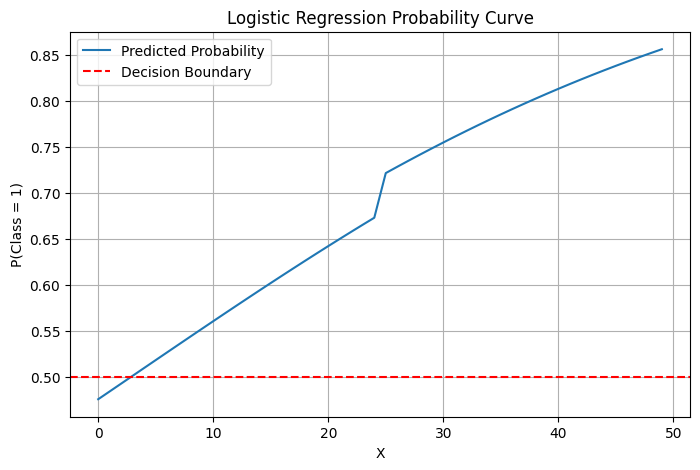

In [27]:
# Dataset
X = np.array([[i] for i in range(50)])

# Rule: class changes at x = 25
Y = np.array([0 if i < 25 else 1 for i in range(len(X))])

# Train model
model = LogisticRegression()
model.fit(X, Y)

probs = model.get_probabilities(X)

plt.figure(figsize=(8, 5))
plt.plot(X.flatten(), probs, label="Predicted Probability")
plt.axhline(0.5, linestyle="--", color="red", label="Decision Boundary")

plt.xlabel("X")
plt.ylabel("P(Class = 1)")
plt.title("Logistic Regression Probability Curve")
plt.legend()
plt.grid(True)
plt.show()